# Exercise: Build a Simplified Search Engine

In this notebook, you will build a simplified search engine using the [Movies Metadata](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?resource=download&select=movies_metadata.csv) dataset.

### Objectives:

1. Learn to preprocess text data from a real dataset.
2. Implement a search function that retrieves the top-N results for a given query.
3. Explore and evaluate different similarity measures (e.g., TF-IDF and cosine similarity).

### Dataset:

You will use the `movies_metadata.csv` file. This dataset contains metadata about movies, including titles, overviews, genres, and other information.

---
### Setup:
Ensure you have the required libraries installed. You may need the following:

```bash
pip install pandas scikit-learn sentence-transformers
```


In [2]:
# Import libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
# Optionally, use Sentence Transformers for semantic similarity
# from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re, string

C:\Users\Utilizador\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Load and Explore the Dataset

Load the `movies_metadata.csv` file and inspect the first few rows. Focus on the `title` and `overview` columns, which will be key for building your search engine.

In [3]:
# Load the dataset
file_path = './data/movies_metadata.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows
df.head()



C:\Users\Utilizador\AppData\Local\Temp\ipykernel_20856\4281909992.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


### Step 2: Preprocess the Data

1. Select relevant columns: `title` and `overview`.
2. Handle missing values by filling them with an empty string.
3. Combine or transform the data as needed for search.

In [4]:
# Preprocess the data
df = df[['title', 'overview', 'genres']].dropna(subset=['title'])
df['overview'] = df['overview'].fillna('')

# Inspect the processed data
df.head()



,title,overview,genres
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]"


### Step 3: Implement the Search Function

Write a function `search(query, n, engine='tfidf')` that retrieves the top-N results for a given query using the specified search engine:

1. **TF-IDF**: Use `TfidfVectorizer` to compute similarity scores.
2. **Sentence Transformers** (optional): Use pre-trained embeddings for semantic search.

#### Hint:
- Compute the similarity between the query and all movie overviews.
- Sort the results by similarity and return the top-N titles.

In [5]:

def clean_text(text):
		text = text.lower()
		punctuation = re.escape(string.punctuation)
		text = re.sub(rf"[\d{punctuation}]", "", text)
		return text.strip()

df['overview'] = df['overview'].astype(str).apply(clean_text)
df['title'] = df['title'].astype(str).apply(clean_text)
df['genres'] = df['genres'].astype(str).apply(clean_text)

# train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [6]:
tfidf_vectorizer = TfidfVectorizer(max_features=100000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['title'] + df["overview"] + df['genres'])


In [7]:
def search(query, n=5, engine='tfidf'):
    """Search for the top-N movies based on the query.

    Args:
        query (str): The search query.
        n (int): Number of top results to return.
        engine (str): Search engine to use ('tfidf' or 'transformer').

    Returns:
        List[str]: Top-N movie titles matching the query.
    """
    query = clean_text(query)
    query_vector = tfidf_vectorizer.transform([query])
    cos_sim_query = cosine_similarity(query_vector, tfidf_matrix)
    top_indices = cos_sim_query[0].argsort()[-n:][::-1]
    similar_documents = df.iloc[top_indices][['title', 'overview', 'genres']]
    return similar_documents['title'], cos_sim_query[0][top_indices]


search("A young mathematician", 5)[1]
    

    

array([0.21022519, 0.18326791, 0.17563616, 0.16657067, 0.15086723])

### Step 4: Test Your Function

Use different queries to test your search function. Verify the quality of the results and experiment with varying `n` values.

In [8]:
# Example usage of the search function
query = 'Space and Galaxies'
top_n = 12
titles, scores = search(query, n=top_n, engine='tfidf')



### Step 5: Plot query and top documents

Plot the query and top retrieved documents or all documents to visualize the retrieval

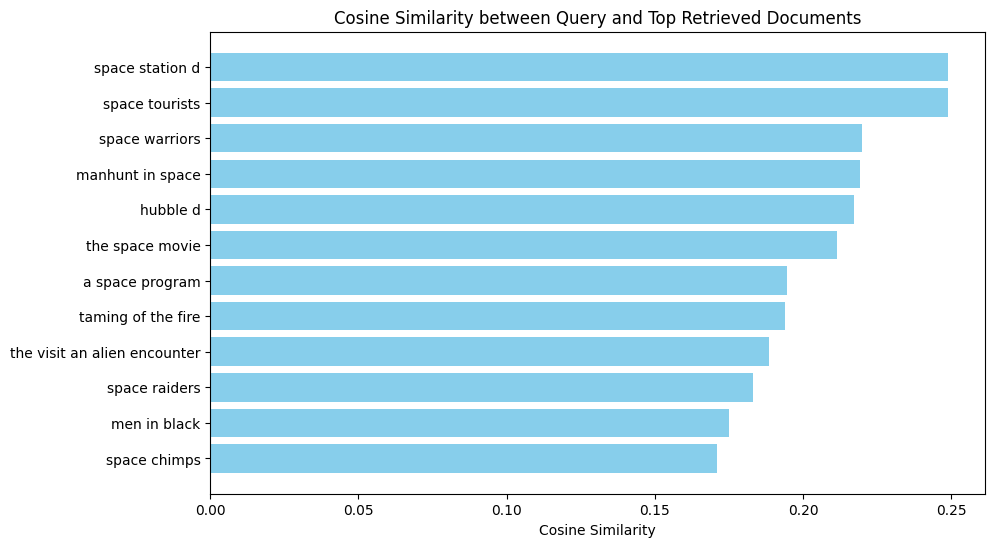

In [9]:

plt.figure(figsize=(10, 6))
plt.barh(titles, scores, color='skyblue')
plt.xlabel('Cosine Similarity')
plt.title('Cosine Similarity between Query and Top Retrieved Documents')
plt.gca().invert_yaxis()  # Invert y-axis so the highest score is at the top
plt.show()

### Step 6: Compare engines

Compare the results of the same query using different engines.

Note: there are multiple ways of doing this, the simpler one is comparing the intersection of top-K (k = 5, 10 or 30) from each engine.

In [13]:
# Optionally, use Sentence Transformers for semantic similarity
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

embeddings = model.encode(df['title'][:18000].astype(str) + df['overview'][:18000].astype(str) + df['genres'][:18000].astype(str), show_progress_bar=True) 


Batches: 100%|██████████| 563/563 [03:47<00:00,  2.47it/s]


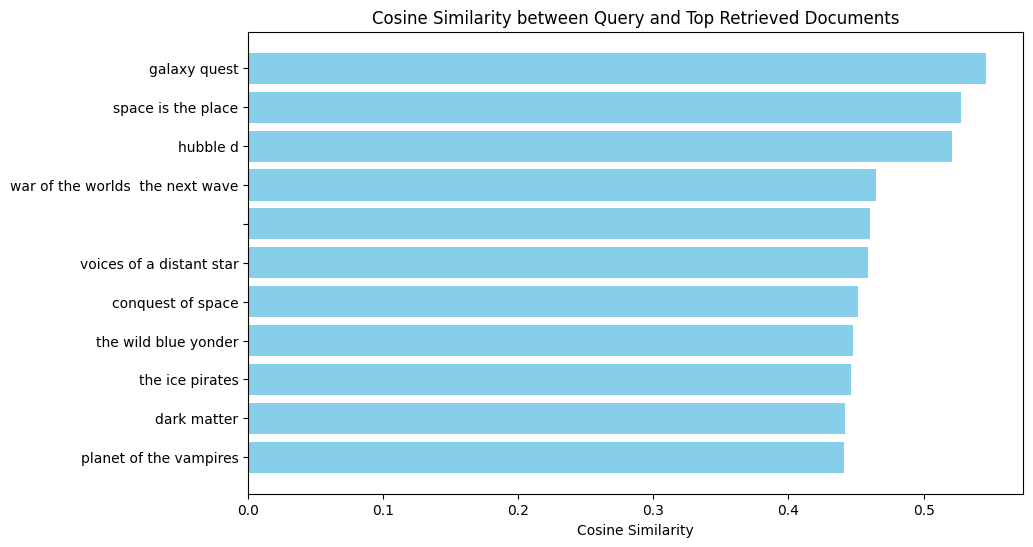

In [19]:
query = clean_text("Space and Galaxy")
encoded_query = model.encode([query])

cos_sim_sentence = cosine_similarity(encoded_query, embeddings)[0]
top_sentence_indices = cos_sim_sentence.argsort()[-12:-1][::-1]

titles = df.iloc[top_sentence_indices][['title', 'overview']]

plt.figure(figsize=(10, 6))
plt.barh(titles['title'], cos_sim_sentence[top_sentence_indices], color='skyblue')
plt.xlabel('Cosine Similarity')
plt.title('Cosine Similarity between Query and Top Retrieved Documents')
plt.gca().invert_yaxis()  # Invert y-axis so the highest score is at the top
plt.show()

### Questions to Think About:

1. How does the choice of similarity measure affect the results?
2. What happens when you use different queries?
3. Can you improve the results by incorporating additional metadata, such as genres?